In [1]:
import warnings
from math import ceil
from json import dumps
from pickle import Pickler
from shutil import rmtree
from pathlib import Path
from typing import Literal
from gzip import open as gz_open
from joblib import Parallel, delayed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, LearningCurveDisplay
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import log_loss, make_scorer
from sklearn.metrics import average_precision_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.stats.outliers_influence import variance_inflation_factor


RANDOM_STATE = 12345
VIF_THRESHOLD = 10.0

# Dados

In [2]:
def prepare_experiment(
    which: Literal["full", "iot", "control", "infra"],
    target: Literal["binary", "grouped", "all"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_{which}_{split}_1sec.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "grouped":
            y_split = split_data["label2"]
        else:
            y_split = split_data["label4"]
        experiment[split] = (split_data, y_split)
    experiment["classes"] = sorted(experiment["train"][1].unique())
    experiment["sample_weight"] = compute_sample_weight(
        class_weight="balanced",
        y=experiment["train"][0]["label_extended"],
    )
    log1p_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    if which == "full":
        experiment["normalizer"] = make_column_transformer(
            (make_pipeline(log1p_transformer, MinMaxScaler()), number_selector),
            (OneHotEncoder(sparse_output=False), ["device_type"]),
            ("passthrough", bool_selector),
            verbose_feature_names_out=False,
        )
    else:
        experiment["normalizer"] = make_column_transformer(
            (make_pipeline(log1p_transformer, MinMaxScaler()), number_selector),
            ("passthrough", bool_selector),
            verbose_feature_names_out=False,
        )
    results_dir = Path("results")
    results_dir /= f"logistic_regression_{which}_{target}"
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError("Experiment already executed and overwrite set to False")
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = str(cache_dir)
    return experiment

In [3]:
experiment = prepare_experiment(which="full", target="binary", overwrite=True)

X_train, y_train = experiment["train"]
sample_weight = experiment["sample_weight"]
class_names = experiment["classes"]
num_classes = len(class_names)
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Colinear features removal

In [4]:
def _vif(data, i):
    with warnings.catch_warnings():
        warnings.simplefilter(action="ignore", category=RuntimeWarning)
        return variance_inflation_factor(data, i)


def get_vif_features_out(
    data: np.ndarray,
    feature_names: list[str],
    vif_threshold: float = 5.0,
    num_samples: int = 30000,
) -> pd.Series:
    feature_names = list(feature_names)
    rng = np.random.default_rng(seed=RANDOM_STATE)
    sample_idxs = rng.choice(data.shape[0], size=num_samples)
    data_sample = np.ones((num_samples, data.shape[1] + 1), dtype=float)
    data_sample[:, :-1] = data[sample_idxs]
    to_remove = {"index": [], "data": []}
    while True:
        vifs = np.array(
            Parallel(n_jobs=6)(
                delayed(_vif)(data_sample, i)
                for i in range(data_sample.shape[1] - 1)
            )
        )
        max_vif_col = vifs.argmax()
        if not vifs[max_vif_col] >= vif_threshold:
            break
        feature_name_out = feature_names.pop(max_vif_col)
        to_remove["data"].append(vifs[max_vif_col])
        to_remove["index"].append(feature_name_out)
        data_sample = np.delete(data_sample, max_vif_col, axis=1)
    return pd.Series(**to_remove, name="vif")

In [5]:
X_train_norm = experiment["normalizer"].fit_transform(X_train)
feature_names_out = experiment["normalizer"].get_feature_names_out().tolist()

In [6]:
vif_removed = results_dir.parent / "vif_removed_features.csv"

# NOTE: This is a very time consuming step.
# Results are saved to avoid recomputing it every time.
if vif_removed.is_file():
    print("Already computed. Reading...")
    vif_out_features = pd.read_csv(vif_removed, index_col="feature")
    vif_out_features = vif_out_features["vif"]
else:
    vif_out_features = get_vif_features_out(X_train_norm, feature_names_out)
    vif_out_features.to_csv(vif_removed, index=True, index_label="feature")

del X_train_norm

vif_out_features

Already computed. Reading...


feature
network_macs_dst_count                       inf
device_type_control                          inf
network_header-length_min           8.248370e+06
network_header-length_avg           6.950146e+05
network_mss_max                     4.593239e+04
                                        ...     
network_packets_src_count           6.378289e+00
network_protocols_src_has_telnet    5.903173e+00
network_ports_src_has_80            5.661157e+00
network_fragmented-packets          5.615247e+00
network_ports_dst_has_554           5.433103e+00
Name: vif, Length: 62, dtype: float64

In [7]:
vif_thres = max(5.0, VIF_THRESHOLD)

vif_remove_indexes = [
    feature_names_out.index(ft)
    for ft in vif_out_features.index
    if vif_out_features[ft] >= vif_thres
]

padding = max(map(lambda x: len(feature_names_out[x]), vif_remove_indexes))
print(f"REMOVED FEATURES (VIF >= {vif_thres:.2f}):")
print("\n".join(
    "{0:02d} - {1} : {2:.2f}".format(
        i,
        feature_names_out[idx].rjust(padding),
        vif_out_features[feature_names_out[idx]],
    )
    for i, idx in enumerate(vif_remove_indexes, start=1)
))

REMOVED FEATURES (VIF >= 10.00):
01 -               network_macs_dst_count : inf
02 -                  device_type_control : inf
03 -            network_header-length_min : 8248369.90
04 -            network_header-length_avg : 695014.59
05 -                      network_mss_max : 45932.39
06 -                      network_mss_avg : 7074.41
07 -          network_fragmentation-score : 7073.37
08 -                network_ip-length_max : 1024.07
09 -            network_packets_all_count : 912.87
10 -            network_header-length_max : 790.92
11 -                network_ip-length_avg : 611.50
12 -                      network_ttl_avg : 427.78
13 -               network_macs_src_count : 310.81
14 -                      network_ttl_max : 257.20
15 -              network_packet-size_avg : 235.61
16 -                network_tcp-flags_avg : 199.20
17 -              network_window-size_max : 192.50
18 -              network_ports_all_count : 187.75
19 -              network_packet-size_max :

# Experiment

## Training pipe

In [8]:
transformer = make_pipeline(
    experiment["normalizer"],
    make_column_transformer(
        ("drop", vif_remove_indexes),
        remainder="passthrough",
        verbose_feature_names_out=False,
    ),
    memory=cache_dir,
)

model = LogisticRegression(
    max_iter=1000,
    l1_ratio=0.0,
    solver="saga",
    tol=1e-4,
    random_state=RANDOM_STATE,
)

In [9]:
train_pipe = Pipeline(
    steps=[("transformer", transformer), ("model", model)],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [10]:
C_range = [10**i for i in range(-5, 5)]
C_range.append(np.inf)

param_grid = {"model__C": C_range}

In [11]:
if num_classes < 3:
    # Average Precision is threshold independent
    refit = "average_precision"
    scoring = {
        refit: make_scorer(
            average_precision_score,
            response_method="decision_function",
            pos_label="attack",
        ),
    }
else:
    # In multiclass classification, thresholding isn't important
    # Just pick the most probable class
    refit = "f1_macro"
    scoring = {refit: make_scorer(f1_score, average="macro")}

In [12]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring=scoring,
    n_jobs=3,
    refit=refit,
    cv=4,
    verbose=3,
)

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=UserWarning)
    grid.fit(X_train, y_train, model__sample_weight=sample_weight)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 11 candidates, totalling 44 fits
[CV 1/4] END .model__C=1e-05; average_precision: (test=0.870) total time=   3.7s
[CV 2/4] END .model__C=1e-05; average_precision: (test=0.874) total time=   4.0s
[CV 3/4] END .model__C=1e-05; average_precision: (test=0.870) total time=   3.9s
[CV 1/4] END model__C=0.0001; average_precision: (test=0.876) total time=   1.9s
[CV 2/4] END model__C=0.0001; average_precision: (test=0.879) total time=   2.2s
[CV 4/4] END .model__C=1e-05; average_precision: (test=0.872) total time=   3.0s
[CV 3/4] END model__C=0.0001; average_precision: (test=0.876) total time=   2.4s
[CV 4/4] END model__C=0.0001; average_precision: (test=0.878) total time=   2.5s
[CV 1/4] END .model__C=0.001; average_precision: (test=0.892) total time=   2.2s
[CV 2/4] END .model__C=0.001; average_precision: (test=0.895) total time=   2.7s
[CV 3/4] END .model__C=0.001; average_precision: (test=0.893) total time=   2.6s
[CV 4/4] END .model__C=0.001; average_precision:

## Cross-validation results

In [13]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by=f"rank_test_{refit}", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)

cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,params,split0_test_average_precision,split1_test_average_precision,split2_test_average_precision,split3_test_average_precision,mean_test_average_precision,std_test_average_precision,rank_test_average_precision
10,82.297823,7.028119,0.201742,0.018514,inf,{'model__C': inf},0.904891,0.906730,0.908419,0.908277,0.907079,0.001426,1
9,86.834903,0.295702,0.228524,0.005377,10000.0000,{'model__C': 10000},0.904891,0.906730,0.908418,0.908277,0.907079,0.001426,2
8,88.677225,0.434613,0.218031,0.008406,1000.0000,{'model__C': 1000},0.904888,0.906739,0.908408,0.908272,0.907077,0.001424,3
7,91.667279,2.741463,0.221554,0.001537,100.0000,{'model__C': 100},0.904823,0.906745,0.908349,0.908231,0.907037,0.001426,4
6,28.526322,1.853639,0.232230,0.009303,10.0000,{'model__C': 10},0.904636,0.906421,0.908066,0.908011,0.906783,0.001405,5
4,1.919086,0.082685,0.229636,0.012145,0.1000,{'model__C': 0.1},0.904741,0.905088,0.906794,0.907987,0.906153,0.001314,6
5,6.390949,0.597381,0.226661,0.005026,1.0000,{'model__C': 1},0.904259,0.905392,0.907022,0.907361,0.906008,0.001255,7
3,2.002512,0.068284,0.238455,0.012181,0.0100,{'model__C': 0.01},0.903344,0.902726,0.903238,0.905818,0.903781,0.001199,8
2,2.299937,0.197118,0.262905,0.028527,0.0010,{'model__C': 0.001},0.892147,0.895097,0.892521,0.895082,0.893712,0.001384,9
1,2.013649,0.215431,0.231894,0.019869,0.0001,{'model__C': 0.0001},0.875645,0.879291,0.875534,0.878111,0.877145,0.001611,10


## Feature importance

In [14]:
importances = np.abs(trained_model.coef_).mean(axis=0).tolist()
feature_names = [
    ft for i, ft in enumerate(feature_names_out)
    if i not in vif_remove_indexes
]
importances.extend([0.0] * len(vif_remove_indexes))
feature_names.extend([feature_names_out[idx] for idx in vif_remove_indexes])
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(feature_importances["importance"])
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

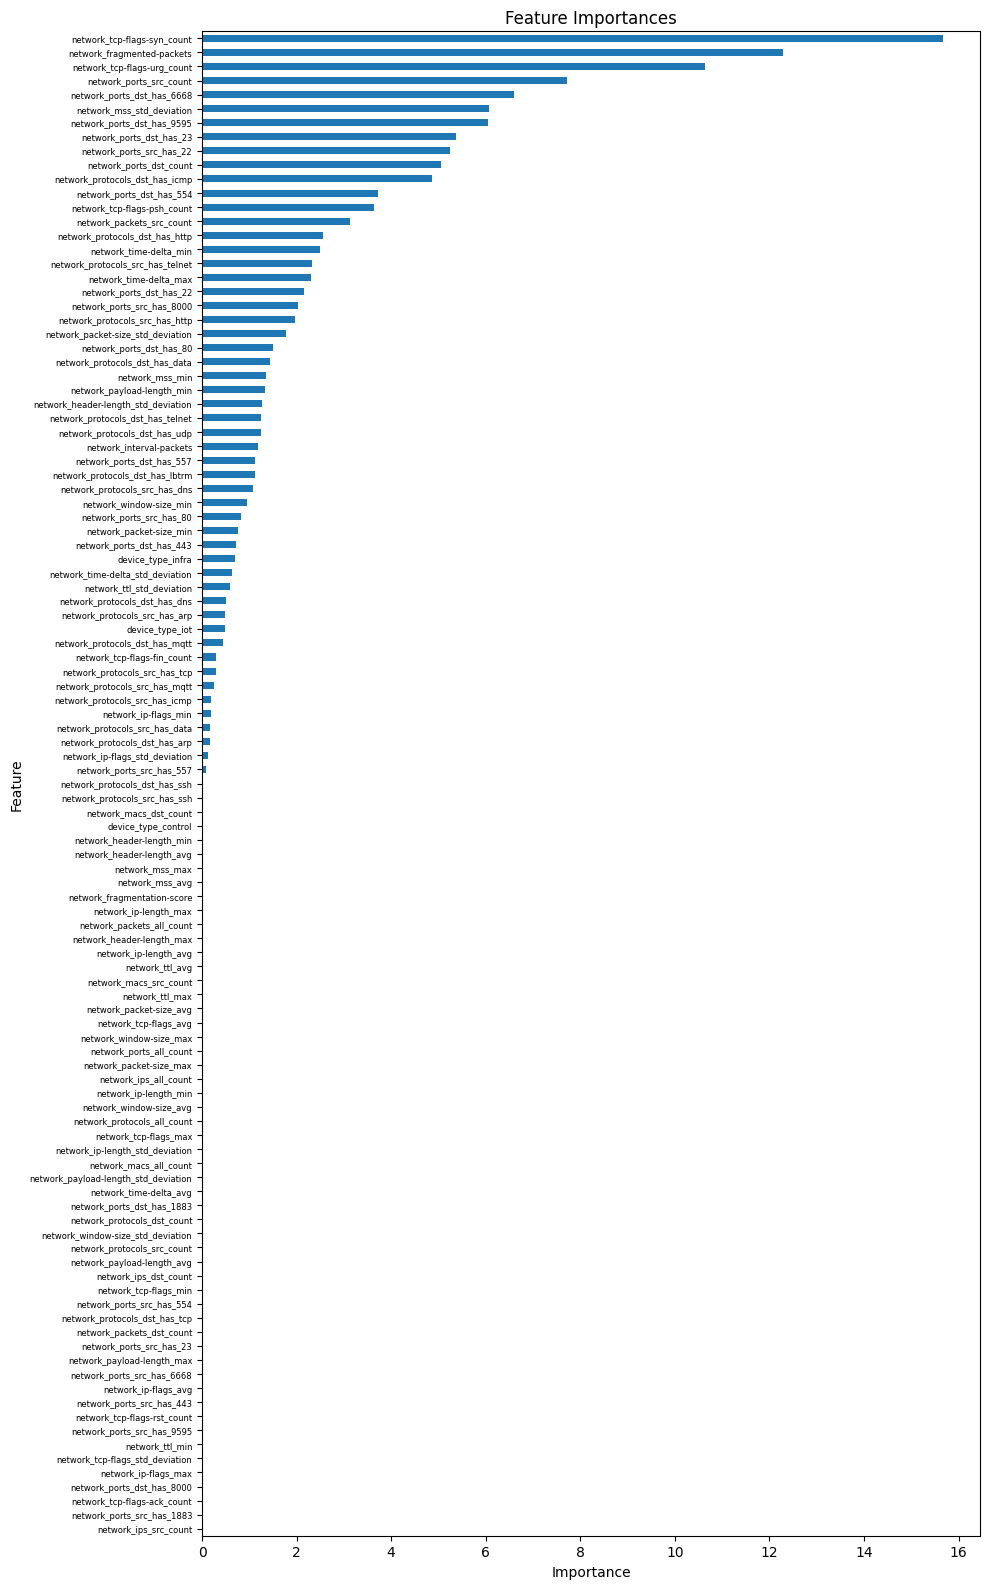

In [15]:
fig, ax = plt.subplots(figsize=(10, 16))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=6,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

## Learning curves

### Sklearn's `learning_curve`

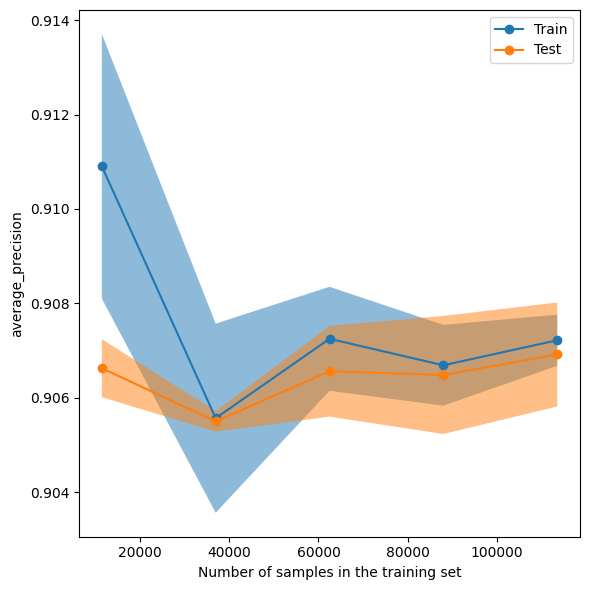

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=UserWarning)
    LearningCurveDisplay.from_estimator(
        estimator=clone(trained_pipe),
        X=X_train,
        y=y_train,
        cv=3,
        n_jobs=3,
        fit_params={"model__sample_weight": sample_weight},
        line_kw={"marker": "o"},
        random_state=RANDOM_STATE,
        scoring=scoring[refit],
        score_name=refit,
        ax=ax,
    )

plt.tight_layout()
plt.show()

### Learning curve with `SGDClassifier`

In [17]:
sgd_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    l1_ratio=0.0,
    alpha=(1 / trained_model.C),
    learning_rate="adaptive",
    warm_start=True,
    random_state=RANDOM_STATE,
)

In [18]:
X = trained_pipe["transformer"].transform(X_train)
y = y_train

X, X_val, y, y_val, weights, weights_val = train_test_split(
    X, y, sample_weight,
    test_size=0.3,
    stratify=X_train["label_extended"],
)

In [19]:
early_stop_iter = trained_model.n_iter_.item()
num_epochs = min(
    100 * ceil(early_stop_iter / 100),
    trained_model.max_iter,
)
loss_history = np.empty((num_epochs, 2))
for epoch in range(num_epochs):
    sgd_model.partial_fit(X, y, classes=class_names, sample_weight=weights)
    loss_history[epoch, 0] = log_loss(y, sgd_model.predict_proba(X))
    loss_history[epoch, 1] = log_loss(y_val, sgd_model.predict_proba(X_val))

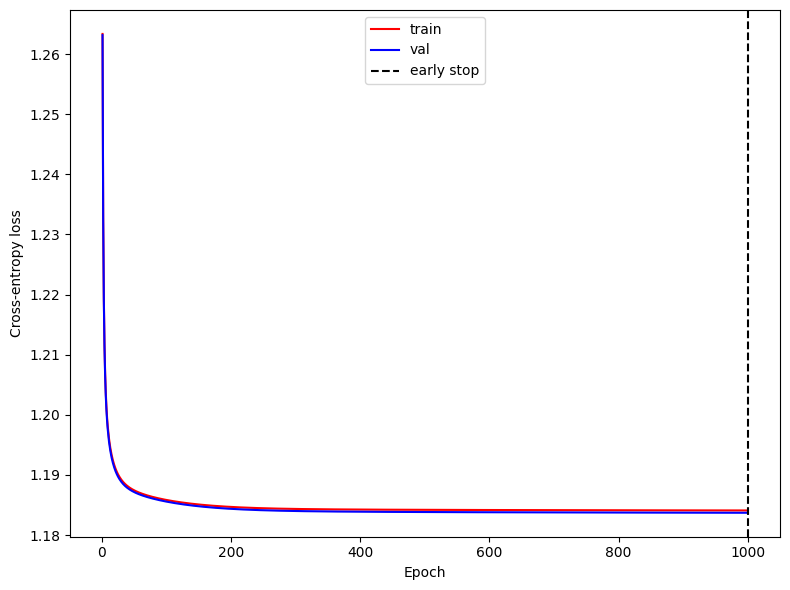

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

epochs = np.arange(1, num_epochs + 1)
ax.plot(epochs, loss_history[:, 0], c="red", label="train")
ax.plot(epochs, loss_history[:, 1], c="blue", label="val")
ax.axvline(early_stop_iter, c="black", ls="--", label="early stop")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.legend()

plt.tight_layout()
plt.show()

# Model evaluations

## Train-split evaluations

In [21]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [22]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [23]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [24]:
model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
}

model_summary = dumps(model_summary, indent=2)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__C": Infinity
  },
  "all_parameters": {
    "C": Infinity,
    "class_weight": null,
    "dual": false,
    "fit_intercept": true,
    "intercept_scaling": 1,
    "l1_ratio": 0.0,
    "max_iter": 1000,
    "n_jobs": null,
    "penalty": "deprecated",
    "random_state": 12345,
    "solver": "saga",
    "tol": 0.0001,
    "verbose": 0,
    "warm_start": false
  }
}
